In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:

df = pd.read_csv("Housing.csv")


df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:

print("Dataset Shape:", df.shape)


print("\nColumns:\n", df.columns)


print("\nDataset Info:")
df.info()

Dataset Shape: (545, 13)

Columns:
 Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishi

In [4]:

print("Null Values Per Column:\n")
print(df.isnull().sum())


duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)


print("\nData Types:\n")
print(df.dtypes)


print("\nStatistical Summary:\n")
print(df.describe())

Null Values Per Column:

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate Rows: 0

Data Types:

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

Statistical Summary:

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    

In [5]:

df_cleaned = df.copy()

In [7]:
print(df_cleaned.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [8]:

print(df_cleaned.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [11]:


numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for col in numeric_cols:
    median_value = df_cleaned[col].median()
    df_cleaned[col] = df_cleaned[col].fillna(median_value)

print("Numerical Missing Values Filled")

Numerical Missing Values Filled


In [12]:
df_cleaned[col] = df_cleaned[col].fillna(median_value)

In [13]:


categorical_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

for col in categorical_cols:
    mode_value = df_cleaned[col].mode()[0]
    df_cleaned[col] = df_cleaned[col].fillna(mode_value)

print("Categorical Missing Values Filled")

Categorical Missing Values Filled


In [14]:


print(df_cleaned.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [15]:

print(df_cleaned.dtypes)

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


In [16]:

df_cleaned['bedrooms'] = df_cleaned['bedrooms'].astype(int)
df_cleaned['bathrooms'] = df_cleaned['bathrooms'].astype(int)
df_cleaned['stories'] = df_cleaned['stories'].astype(int)
df_cleaned['parking'] = df_cleaned['parking'].astype(int)

print("Data Types Corrected")

Data Types Corrected


In [17]:

categorical_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].str.lower().str.strip()

print("Standardisation Completed")

Standardisation Completed


In [18]:


for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df_cleaned[col].unique())


Unique values in mainroad:
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

Unique values in guestroom:
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

Unique values in basement:
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

Unique values in hotwaterheating:
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

Unique values in airconditioning:
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

Unique values in prefarea:
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

Unique values in furnishingstatus:
<ArrowStringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


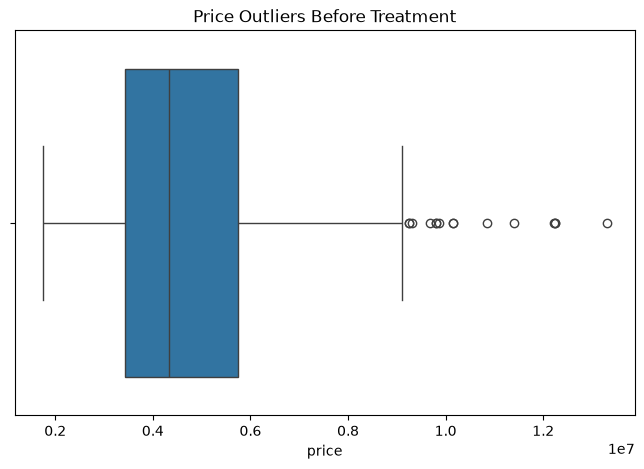

In [19]:


plt.figure(figsize=(8,5))

sns.boxplot(x=df_cleaned['price'])

plt.title("Price Outliers Before Treatment")

plt.show()

In [20]:


Q1 = df_cleaned['price'].quantile(0.25)
Q3 = df_cleaned['price'].quantile(0.75)

IQR = Q3 - Q1



lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR



df_cleaned = df_cleaned[
    (df_cleaned['price'] >= lower_bound) &
    (df_cleaned['price'] <= upper_bound)
]

print("Outliers Removed Successfully")

Outliers Removed Successfully


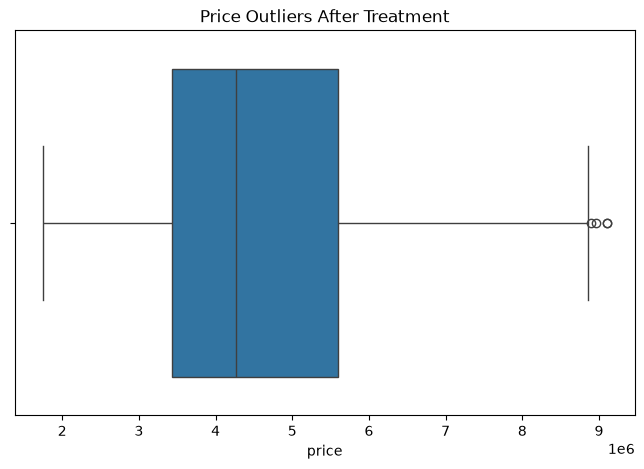

In [21]:


plt.figure(figsize=(8,5))

sns.boxplot(x=df_cleaned['price'])

plt.title("Price Outliers After Treatment")

plt.show()

In [22]:


summary = pd.DataFrame({

    'Metric': [
        'Row Count',
        'Duplicate Rows',
        'Total Null Values'
    ],

    'Before Cleaning': [
        len(df),
        df.duplicated().sum(),
        df.isnull().sum().sum()
    ],

    'After Cleaning': [
        len(df_cleaned),
        df_cleaned.duplicated().sum(),
        df_cleaned.isnull().sum().sum()
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Row Count,545,530
1,Duplicate Rows,0,0
2,Total Null Values,0,0


In [23]:

print("Original Dataset Shape:", df.shape)

print("Cleaned Dataset Shape:", df_cleaned.shape)

Original Dataset Shape: (545, 13)
Cleaned Dataset Shape: (530, 13)


In [24]:


df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 530 entries, 15 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             530 non-null    int64
 1   area              530 non-null    int64
 2   bedrooms          530 non-null    int32
 3   bathrooms         530 non-null    int32
 4   stories           530 non-null    int32
 5   mainroad          530 non-null    str  
 6   guestroom         530 non-null    str  
 7   basement          530 non-null    str  
 8   hotwaterheating   530 non-null    str  
 9   airconditioning   530 non-null    str  
 10  parking           530 non-null    int32
 11  prefarea          530 non-null    str  
 12  furnishingstatus  530 non-null    str  
dtypes: int32(4), int64(2), str(7)
memory usage: 59.4 KB


In [25]:


df_cleaned.to_csv("cleaned_housing_dataset.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [26]:


df_cleaned.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
16,9100000,6600,4,2,2,yes,yes,yes,no,yes,1,yes,unfurnished
17,8960000,8500,3,2,4,yes,no,no,no,yes,2,no,furnished
18,8890000,4600,3,2,2,yes,yes,no,no,yes,2,no,furnished
19,8855000,6420,3,2,2,yes,no,no,no,yes,1,yes,semi-furnished


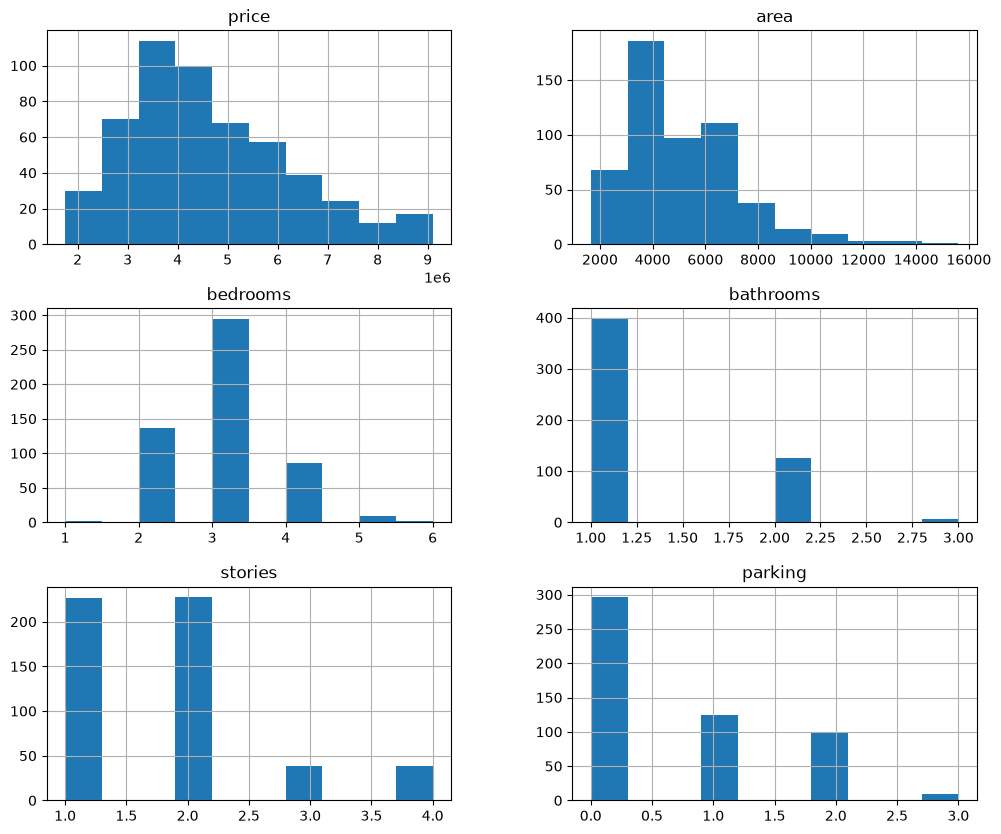

In [27]:


df_cleaned.hist(figsize=(12,10))

plt.show()

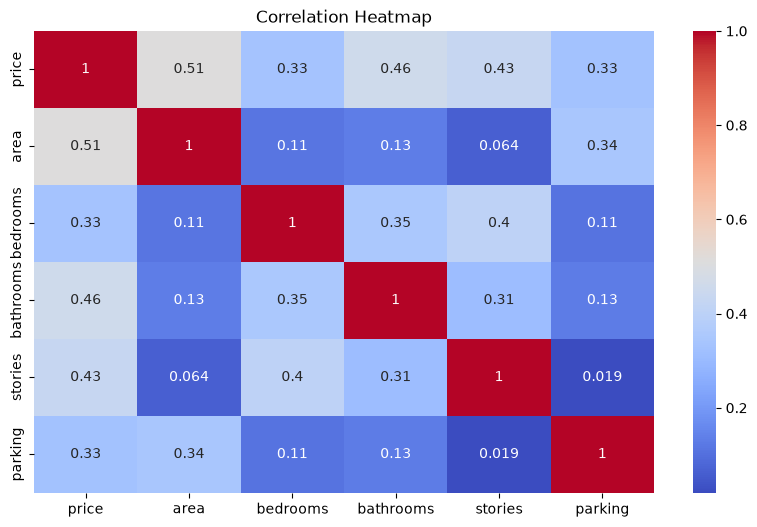

In [28]:


plt.figure(figsize=(10,6))

sns.heatmap(df_cleaned.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()